In [15]:
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd
import os
from pathlib import Path

common_path = "/home/usuario/Madgraph/projects/"

Delphes = "HL-LHC"
Energy_label = "14TeV"

data_to_analyse = f"{Delphes}_{Energy_label}"

signal = up.open(common_path + f"/gg_hh-LQs/signal/Events/{data_to_analyse}_signal/tag_1_delphes_events.root")
sm = up.open(common_path + f"/gg_hh-sm/Events/{data_to_analyse}_SM/tag_1_delphes_events.root")
bg = up.open(common_path + f"/gg_tth_hdecaylep/Events/{data_to_analyse}_bg_hlep/tag_1_delphes_events.root")

signal_tree = signal["Delphes"]
sm_tree = sm["Delphes"]
bg_tree = bg["Delphes"]

folder_path = f'/home/usuario/VSCode/diHiggs-Project/RecAnalysis/{data_to_analyse}'

os.makedirs(folder_path, exist_ok=True)

vec.register_awkward()

In [16]:
def calculo_rangos(lim_inf, lim_sup, data):

    if type(data) == list:

        total_events = sum(len(data_i) for data_i in data)

        debajo = sum(np.sum(data_i < lim_inf) for data_i in data)

        dentro = sum(
            np.sum((data_i >= lim_inf) & (data_i <= lim_sup))
            for data_i in data
        )

        encima = sum(np.sum(data_i > lim_sup) for data_i in data)

        p_debajo = 100 * debajo / total_events
        p_dentro = 100 * dentro / total_events
        p_encima = 100 * encima / total_events

        return lim_inf, lim_sup, p_debajo, p_dentro, p_encima

    else:

        return print("Error: data debe ser una lista de arrays de datos.")

def misstag_stats(data):
    n_double = ak.sum((data["Jet.TauTag"] > 0) & (data["Jet.BTag"] > 0))
    n_tau    = ak.sum((data["Jet.TauTag"] > 0)) 
    pct      = 100 * n_double / n_tau if n_tau else 0.0
    return int(n_double), int(n_tau), pct

def vectors_buildup(data):
    jets = ak.zip({
        "pt": data["Jet.PT"],
        "eta": data["Jet.Eta"],
        "phi": data["Jet.Phi"],
        "mass": data["Jet.Mass"],
        'TauTag': data["Jet.TauTag"],
        'BTag': data["Jet.BTag"],
    }, with_name="Momentum4D")

    tracks = ak.zip({
        "pt": data["Track.PT"],
        "eta": data["Track.Eta"],
        "phi": data["Track.Phi"],
        "mass": data["Track.Mass"],
        "d0":  data["Track.D0"],  
        "dz":  data["Track.DZ"]
    }, with_name="Momentum4D")

    return jets, tracks

In [22]:
def MET_trigger(data, MET_lowerbond):

    MET_mask = ak.flatten(data["MissingET.MET"]) > MET_lowerbond

    return MET_mask

def cinematic_cut(vec, Pt_lowerBond, Eta_absoluteBond):
    cinematic_mask = (vec.pt > Pt_lowerBond) & (abs(vec.eta) < Eta_absoluteBond)
    return cinematic_mask

def Selected_data(data, MET_LB, PT_LB, Eta_AB):

    MET_mask = MET_trigger(data, MET_LB)

    data_selected = data[MET_mask]

    # Construyo los jets, con su cuadrivector y los BTag y tautag

    jets_select, tracks_select = vectors_buildup(data_selected)

    cinematic_mask = cinematic_cut(jets_select, PT_LB, Eta_AB)

    jets_select, tracks_select = jets_select[cinematic_mask], tracks_select[cinematic_mask]

    return jets_select, tracks_select

def Taus_and_bjets(jets):
    taus = jets[(jets['TauTag'] == 1) & (jets['BTag'] == 0)]
    bjets = jets[(jets['TauTag'] == 0) & (jets['BTag'] == 1)]

    N_events = len(ak.sum(jets, axis=1))
    N_taus = ak.num(taus, axis=1)
    N_bjets = ak.num(bjets, axis=1)

    return taus, bjets, N_events, N_taus, N_bjets

def kinematic_hierarchical_order(taus, bjets):
    mask  = (ak.num(taus) >= 2) & (ak.num(bjets) >= 2)
    taus_cut, bjets_cut = taus[mask], bjets[mask]
    tau1, tau2 = taus_cut[:,0], taus_cut[:,1]
    b1, b2     = bjets_cut[:,0], bjets_cut[:,1]
    return tau1, tau2, b1, b2, taus_cut, bjets_cut


def InvariantMass_of_products(tau1, tau2, b1, b2):
    M_tautau = (tau1+tau2).mass
    M_bb     = (b1+b2).mass
    M_hh     = (tau1+tau2+b1+b2).mass

    return M_tautau, M_bb, M_hh

def misstag_pct(jets):
    n_tau = ak.sum(jets['TauTag'] > 0)
    if n_tau == 0:
        return 0.0
    return 100 * ak.sum((jets['BTag'] > 0) & (jets['TauTag'] > 0)) / n_tau

In [23]:
extracted_keys = ["Jet.PT","Jet.Eta", "Jet.Phi", "Jet.Mass", "Jet.BTag","Jet.TauTag", "MissingET.MET",
            'Track.PT', 'Track.Eta', 'Track.Phi', 'Track.Mass', 'Track.PID', 'Track.DZ', 'Track.D0', 'Track.Charge']

data_sl = signal_tree.arrays(extracted_keys)
data_bg = bg_tree.arrays(extracted_keys)
data_sm = sm_tree.arrays(extracted_keys)

# Parámetros a definir

MET_trigger_list = [0, 20, 50, 70, 100, 150]     # GeV
PT_LowerBond = 20       # GeV
Eta_AbsoluteBond = 2.5

list_InvarianMass = []
list_DeltaR_tautau = []
list_DeltaR_bb = []
list_aceptancia = []
list_doubletag  = []

for MET_LowerBond in MET_trigger_list:

    # Seleccion de Jets y Tracks con Met aceptada

    jets_sl, tracks_sl = Selected_data(data_sl, MET_LowerBond, PT_LowerBond, Eta_AbsoluteBond)
    jets_bg, tracks_bg = Selected_data(data_bg, MET_LowerBond, PT_LowerBond, Eta_AbsoluteBond)
    jets_sm, tracks_sm = Selected_data(data_sm, MET_LowerBond, PT_LowerBond, Eta_AbsoluteBond)

    # Ahora separo en taus y bs

    taus_sl, bjets_sl, N_events_sl, N_taus_sl, N_bjets_sl = Taus_and_bjets(jets_sl)
    taus_bg, bjets_bg, N_events_bg, N_taus_bg, N_bjets_bg = Taus_and_bjets(jets_bg)
    taus_sm, bjets_sm, N_events_sm, N_taus_sm, N_bjets_sm = Taus_and_bjets(jets_sm)

    # Selección de eventos con 2 taus y 2 b-jets

    tau1_sl, tau2_sl, b1_sl, b2_sl, taus_cut_sl, bjets_cut_sl = kinematic_hierarchical_order(taus_sl, bjets_sl)
    tau1_bg, tau2_bg, b1_bg, b2_bg, taus_cut_bg, bjets_cut_bg = kinematic_hierarchical_order(taus_bg, bjets_bg)
    tau1_sm, tau2_sm, b1_sm, b2_sm, taus_cut_sm, bjets_cut_sm = kinematic_hierarchical_order(taus_sm, bjets_sm)

    # Calculo la masa invariante

    LQ_m_tautau, LQ_m_bb, LQ_m_hh = InvariantMass_of_products(tau1_sl, tau2_sl, b1_sl, b2_sl)
    BG_m_tautau, BG_m_bb, BG_m_hh = InvariantMass_of_products(tau1_bg, tau2_bg, b1_bg, b2_bg)
    SM_m_tautau, SM_m_bb, SM_m_hh = InvariantMass_of_products(tau1_sm, tau2_sm, b1_sm, b2_sm)

    # Distribución de DeltaR entre los pares tau-tau y b-b

    DeltaR_tautau_SL = tau1_sl.deltaR(tau2_sl)
    DeltaR_bb_SL = b1_sl.deltaR(b2_sl)

    DeltaR_tautau_SM = tau1_sm.deltaR(tau2_sm)
    DeltaR_bb_SM = b1_sm.deltaR(b2_sm)

    DeltaR_tautau_BG = tau1_bg.deltaR(tau2_bg)
    DeltaR_bb_BG = b1_bg.deltaR(b2_bg)

    acc = (100 * len(taus_cut_sl) / N_events_sl if N_events_sl else 0.0,
        100 * len(taus_cut_bg) / N_events_bg if N_events_bg else 0.0,
        100 * len(taus_cut_sm) / N_events_sm if N_events_sm else 0.0)

    dbl = (misstag_pct(jets_sl), misstag_pct(jets_bg), misstag_pct(jets_sm))

    list_aceptancia.append(acc)
    list_doubletag.append(dbl)

    # Construyo las tuplas

    tuple_IM = (LQ_m_hh, BG_m_hh, SM_m_hh)
    tuple_DR_tautau = (DeltaR_tautau_SL, DeltaR_tautau_BG, DeltaR_tautau_SM) 
    tuple_DR_bb = (DeltaR_bb_SL, DeltaR_bb_BG, DeltaR_bb_SM) 

    # Añado a la lista

    list_InvarianMass.append(tuple_IM)
    list_DeltaR_tautau.append(tuple_DR_tautau)
    list_DeltaR_bb.append(tuple_DR_bb)


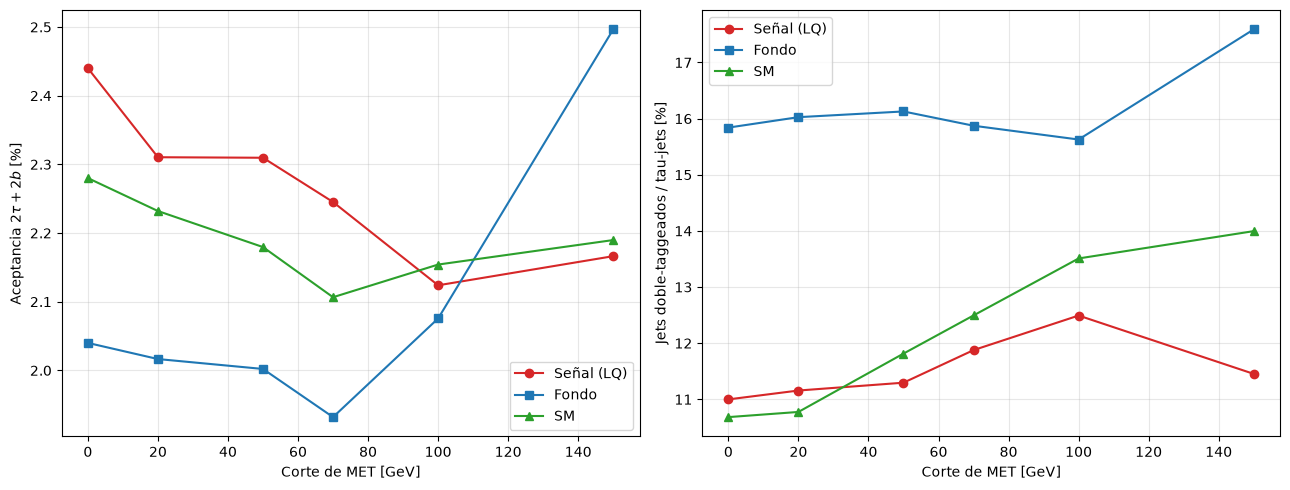

In [25]:
etiquetas = ["Señal (LQ)", "Fondo", "SM"]
colores   = ["tab:red", "tab:blue", "tab:green"]
marcas    = ["o", "s", "^"]

acc = np.array(list_aceptancia)      # (6, 3)
dbl = np.array(list_doubletag)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for i, (lab, col, mk) in enumerate(zip(etiquetas, colores, marcas)):
    axes[0].plot(MET_trigger_list, acc[:, i], marker=mk, color=col, label=lab)
    axes[1].plot(MET_trigger_list, dbl[:, i], marker=mk, color=col, label=lab)

axes[0].set_ylabel(r"Aceptancia $2\tau + 2b$ [%]")
axes[1].set_ylabel("Jets doble-taggeados / tau-jets [%]")

for ax in axes:
    ax.set_xlabel("Corte de MET [GeV]")
    ax.grid(alpha=0.3)
    ax.legend()

fig.tight_layout()
fig.savefig(f"{folder_path}/Aceptancia_y_DobleTag_vs_MET.png", dpi=300)
plt.show()

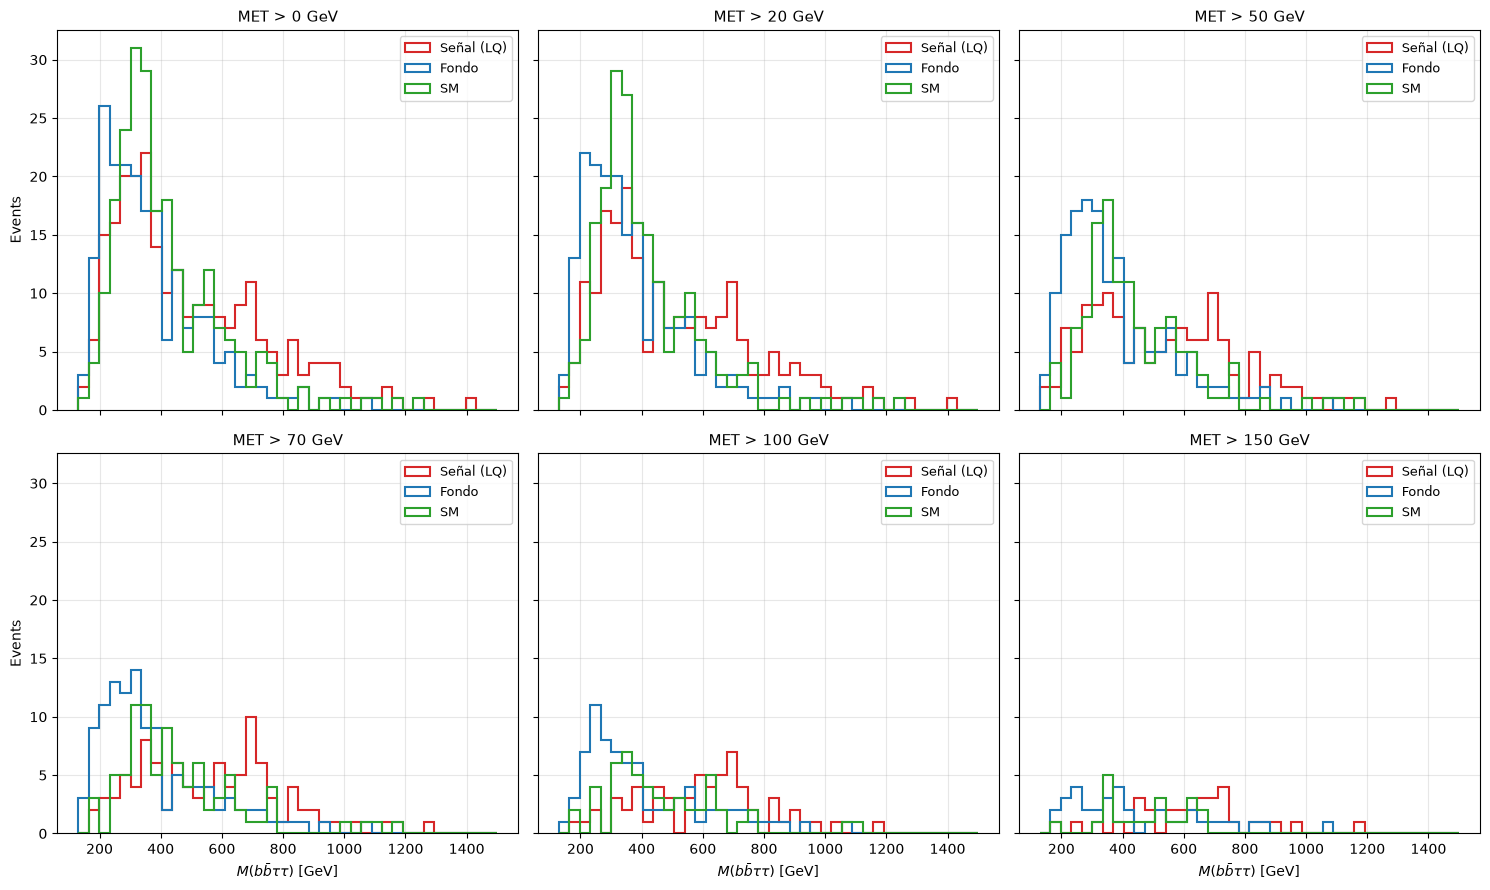

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

etiquetas = ["Señal (LQ)", "Fondo", "SM"]
colores   = ["tab:red", "tab:blue", "tab:green"]
kw = dict(bins=40, range=(130, 1500), density=False, histtype="step", linewidth=1.5)

for ax, met, tuple_IM in zip(axes.flat, MET_trigger_list, list_InvarianMass):
    for datos, lab, col in zip(tuple_IM, etiquetas, colores):
        ax.hist(ak.to_numpy(datos), label=lab, color=col, **kw)
    ax.set_title(f"MET > {met} GeV", fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$M(b\bar{b}\tau\tau)$ [GeV]")
for ax in axes[:, 0]:
    ax.set_ylabel("Events")

fig.tight_layout()

fig.savefig(f"{folder_path}/InvMass_vs_MET.png", dpi=300)
plt.show()

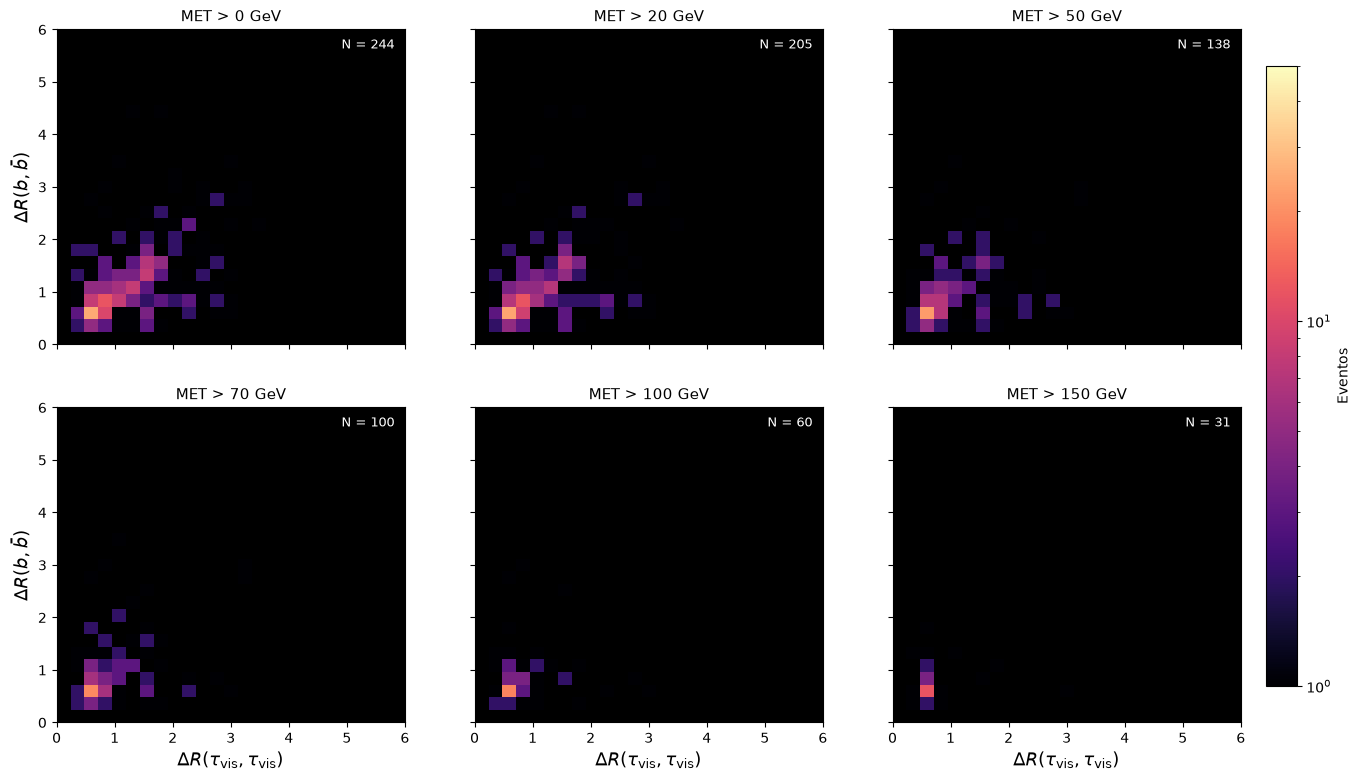

In [20]:
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)

rango = [[0, 6], [0, 6]]
norm  = LogNorm(vmin=1, vmax=50)

for ax, met, tup_tt, tup_bb in zip(axes.flat, MET_trigger_list,
                                   list_DeltaR_tautau, list_DeltaR_bb):
    x = ak.to_numpy(tup_tt[0])
    y = ak.to_numpy(tup_bb[0])
    h = ax.hist2d(x, y, bins=25, range=rango,
                  cmap="magma", norm=norm, cmin=1)
    ax.set_title(f"MET > {met} GeV", fontsize=11)
    ax.text(0.97, 0.97, f"N = {len(x)}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="white")
    ax.set_facecolor("black")

for ax in axes[-1, :]:
    ax.set_xlabel(r"$\Delta R(\tau_{\rm vis},\tau_{\rm vis})$", fontsize=13)
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\Delta R(b,\bar{b})$", fontsize=13)

fig.colorbar(h[3], ax=axes, label="Eventos", fraction=0.025, pad=0.02)

fig.savefig(f"{folder_path}/2D-DeltaR_vs_MET.png", dpi=300)
plt.show()